<a href="https://colab.research.google.com/github/pinakm9/fp-solvers/blob/master/colab-plotters/L63_steady.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# run this cell to download data and necessary modules
import os, shutil
repo = 'fp-solvers'
if os.path.isdir(repo):
  shutil.rmtree(repo)
!git clone https://github.com/pinakm9/fp-solvers.git
# add modules folder to Python's search path
import sys
sys.path.insert(0, repo + '/modules')
# import the rest of the modules
%matplotlib nbagg
%matplotlib inline
import numpy as np
import tensorflow as tf 
import matplotlib.pyplot as plt
import arch
import pandas as pd
import tensorflow_probability as tfp
import time  
import sim
from mpl_toolkits.axes_grid1 import make_axes_locatable
import integrator as it
import utility as ut
DTYPE = 'float32'

# load learned solution
dim = 3
net = arch.LSTMForgetNet(50, 3, tf.float32, name="L63")
net.load_weights('{}/non-grad3D/data/L63/1M/{}'.format(repo, net.name)).expect_partial()
X = tf.random.uniform(shape=(10, dim))
net(*tf.split(X, dim, axis=-1))

# memory-safe version of the solution
def p_inf(X):
        m = int(1e4)
        M = int(np.ceil(len(X) / m))
        data = []
        for i in range(M):
            if i < M-1:
                x = X[i*m: (i+1)*m]
            else:
                x = X[i*m:] 
            data.append(np.exp(net(x)))
        return np.concatenate(data, axis=0)

# compute Monte-Carlo estimate
dim = 3
n_particles = int(1e7)
n_subdivisions = 100
save_folder = '{}/non-grad3D/data/L63'.format(repo)
n_steps = 1000
dt = 0.01
alpha, beta, rho = 10., 8./3., 28.
sigma = 10.
D = sigma**2 / 2.
t = dt * n_steps
r = 1.0
# low=[-20., -20., -20.]
# high=[20., 30., 80.]
# domain = [low, high]

def mu_np(X):
    x, y, z = np.split(X, dim, axis=-1)
    p = alpha * (y - x) 
    q = x * (rho - z) - y 
    r = x * y - beta * z
    return np.concatenate([p, q, r], axis=-1)


X0 =  tfp.distributions.MultivariateNormalDiag(scale_diag=r*tf.ones(dim)).sample(n_particles).numpy()
mc_prob = sim.MCProb(save_folder, n_subdivisions, mu_np, sigma, X0, tick_size=20, title_size=20, cbar_tick_size=15)
mc_prob.ready(n_steps=n_steps, dt=dt, lims=None)
#mc_prob.compute_all(n_steps=n_steps, dt=dt)

# projecter for 3D to 2D
@ut.timer
def projector(net, low, high, idx, n_subdivs, n_int_subdivs, dtype='float32'):
  x = np.linspace(low[idx[0]], high[idx[0]], num=n_subdivs+1, endpoint=True).astype(dtype)[1:]
  y = np.linspace(low[idx[1]], high[idx[1]], num=n_subdivs+1, endpoint=True).astype(dtype)[1:]
  q = it.Gauss_Legendre([low[idx[2]], high[idx[2]]], n_int_subdivs, 10, dtype)
  z = q.nodes.reshape(-1, 1)
  delta = (high[idx[0]] - low[idx[0]]) * (high[idx[1]] - low[idx[1]]) / (n_subdivs)**2
  delta_z = (high[idx[2]] - low[idx[2]]) / n_int_subdivs
  prob = np.zeros((n_subdivs, n_subdivs))
  ones = tf.ones_like(z)
  for i in range(n_subdivs):
    for j in range(n_subdivs):
      X = tf.concat([e for _, e in sorted(zip(idx, [x[i]*ones, y[j]*ones, z]))], axis=-1).numpy()
      prob[i, j] = q.quad(p_inf(X).flatten())
      print('Calculating probability for {} at {}'.format(idx, (i, j)), end='\n')
  prob /= (prob.sum()*delta)
  return prob

Cloning into 'fp-solvers'...
remote: Enumerating objects: 14790, done.
remote: Counting objects: 100% (160/160), done.
remote: Compressing objects: 100% (96/96), done.
remote: Total 14790 (delta 65), reused 141 (delta 57), pack-reused 14630
Receiving objects: 100% (14790/14790), 796.98 MiB | 17.83 MiB/s, done.
Resolving deltas: 100% (7220/7220), done.
Updating files: 100% (14649/14649), done.


Streaming output truncated to the last 5000 lines.
Calculating probability for [2, 0, 1] at (50, 2)
Calculating probability for [2, 0, 1] at (50, 3)
Calculating probability for [2, 0, 1] at (50, 4)
Calculating probability for [2, 0, 1] at (50, 5)
Calculating probability for [2, 0, 1] at (50, 6)
Calculating probability for [2, 0, 1] at (50, 7)
Calculating probability for [2, 0, 1] at (50, 8)
Calculating probability for [2, 0, 1] at (50, 9)
Calculating probability for [2, 0, 1] at (50, 10)
Calculating probability for [2, 0, 1] at (50, 11)
Calculating probability for [2, 0, 1] at (50, 12)
Calculating probability for [2, 0, 1] at (50, 13)
Calculating probability for [2, 0, 1] at (50, 14)
Calculating probability for [2, 0, 1] at (50, 15)
Calculating probability for [2, 0, 1] at (50, 16)
Calculating probability for [2, 0, 1] at (50, 17)
Calculating probability for [2, 0, 1] at (50, 18)
Calculating probability for [2, 0, 1] at (50, 19)
Calculating probability for [2, 0, 1] at (50, 20)
Calcula

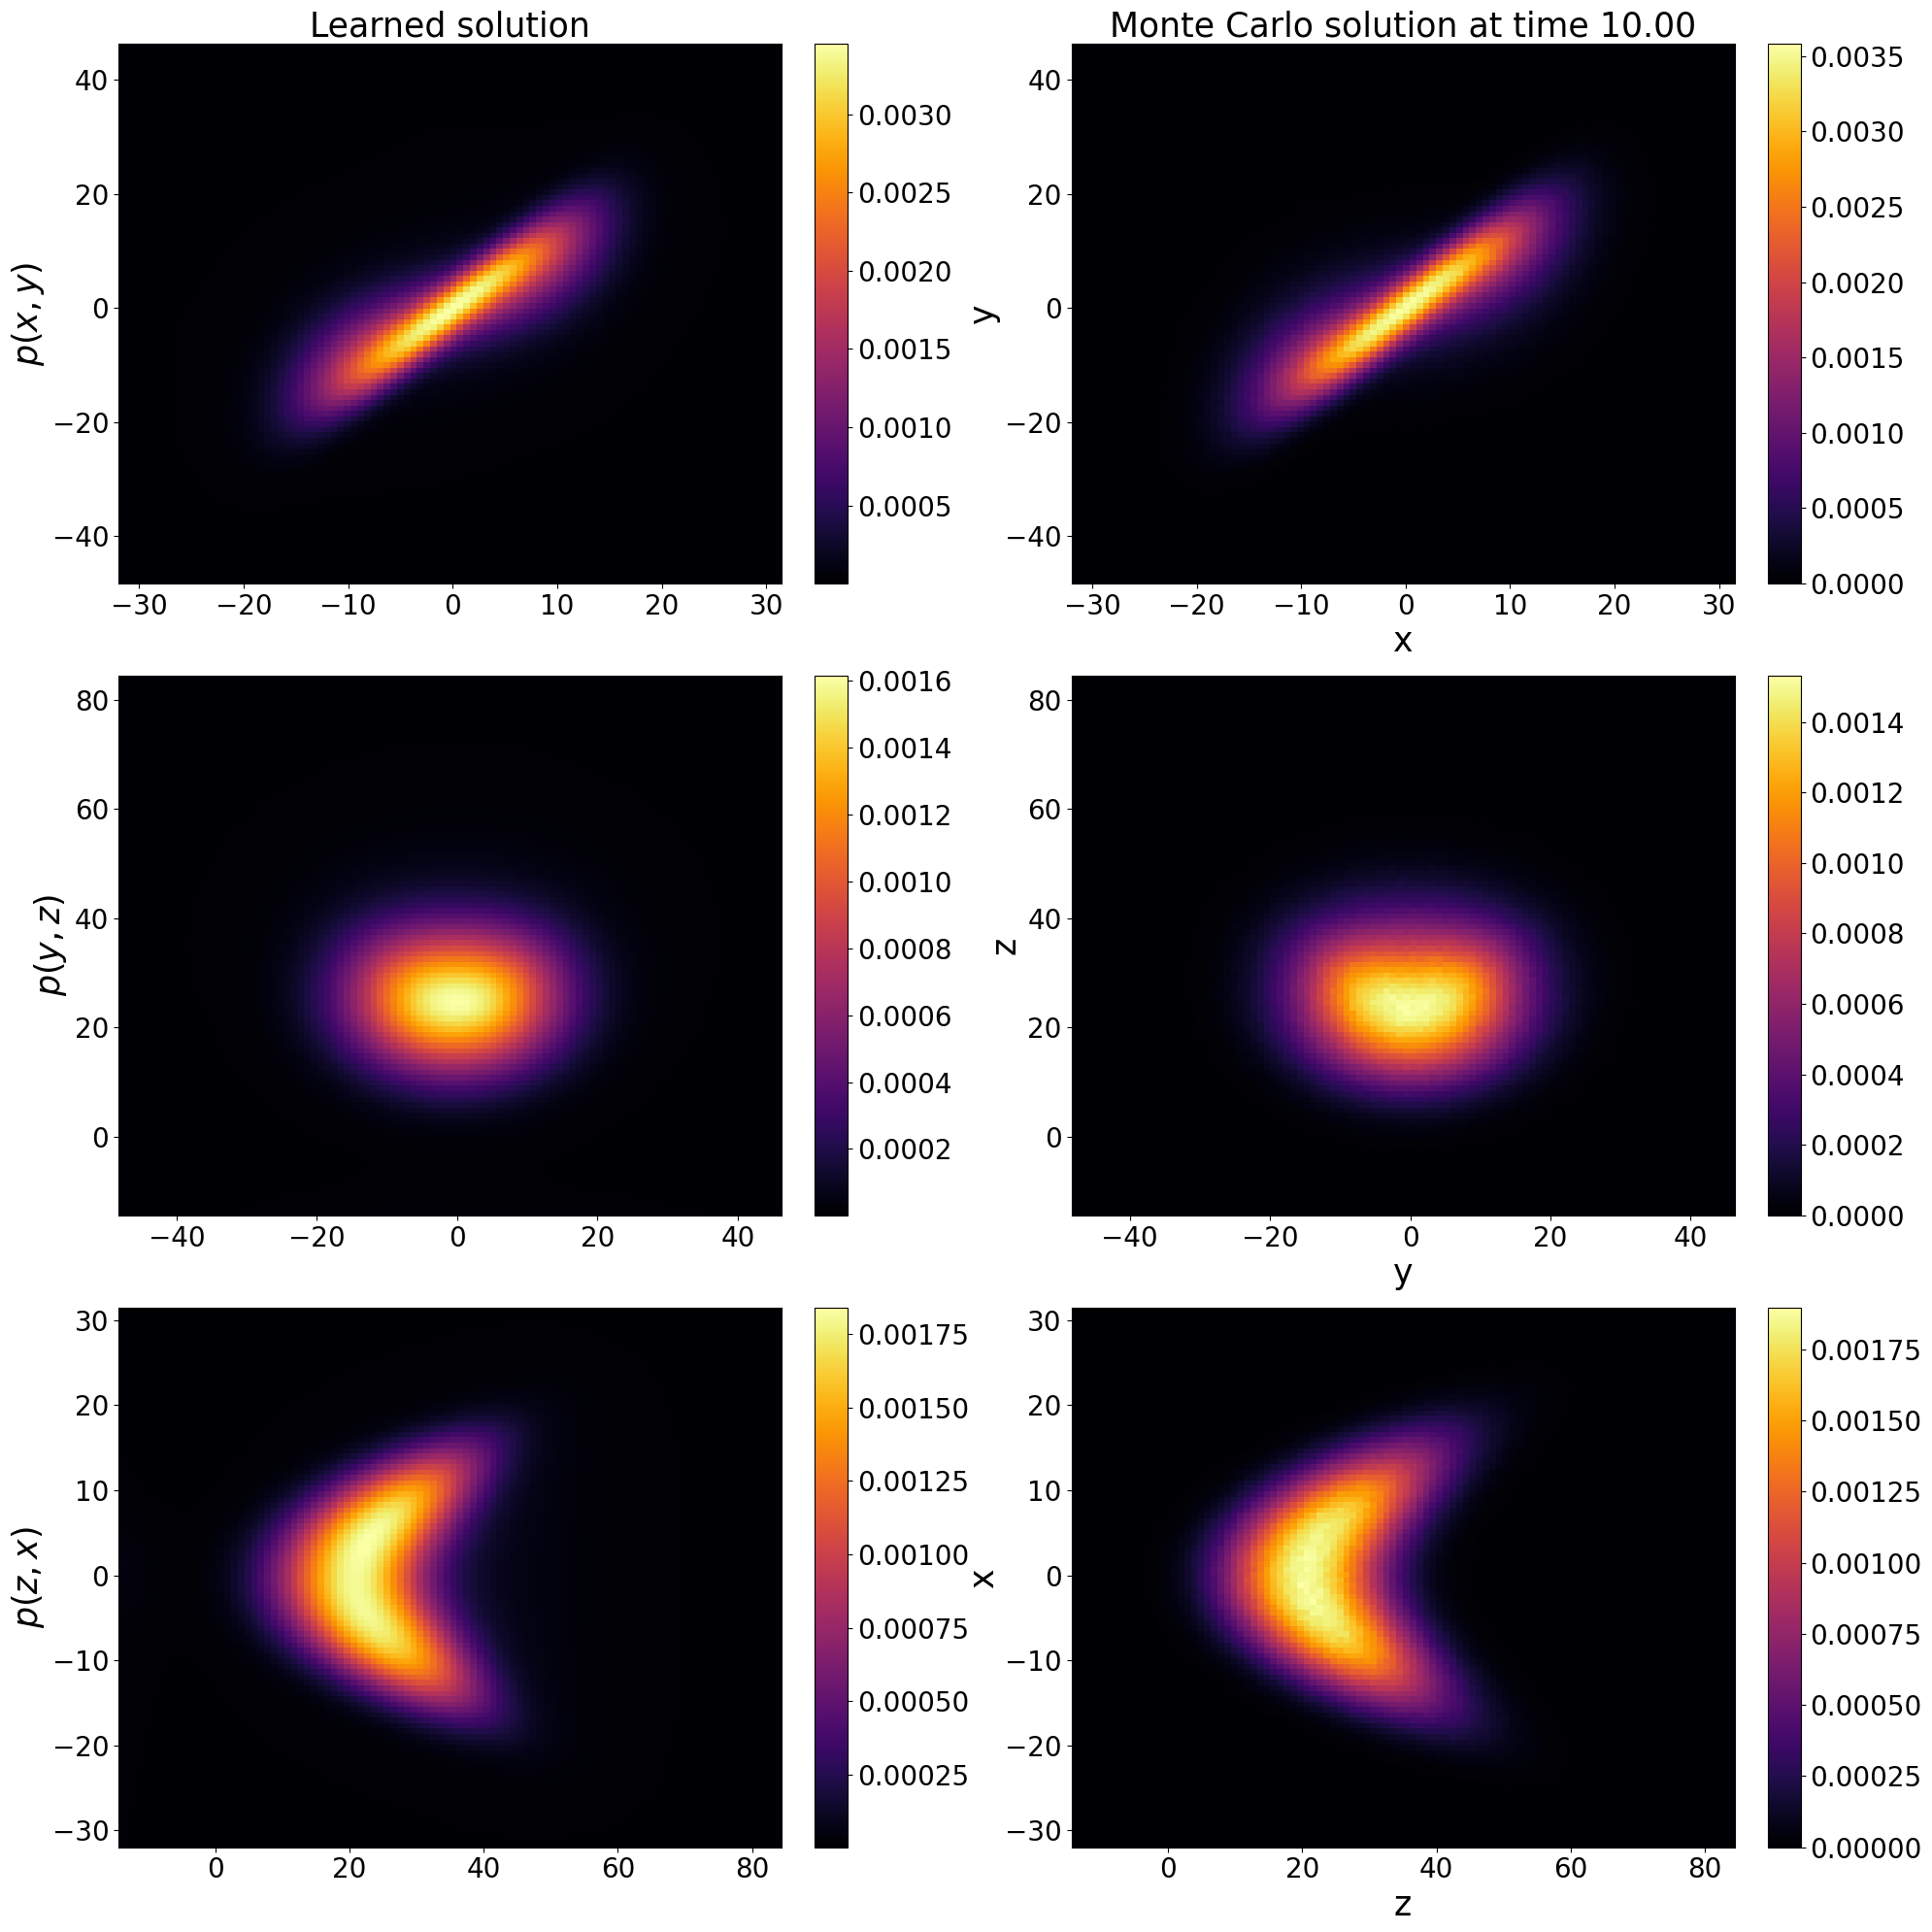

In [ ]:
# set up plotting parameters
scale = 10
xlabel_size = ylabel_size = 15 + scale
tick_size = 10 + scale
legend_size = 15 + scale
title_size = 15 + scale
cbar_tick_size = 10 + scale
start = time.time()
grid = mc_prob.get_grid()
low = grid.mins
high = grid.maxs
n_subdivs = n_subdivisions
n_int_subdivs = 500

x_ = np.linspace(low[0], high[0], num=n_subdivs, endpoint=True).astype('float32')
y_ = np.linspace(low[1], high[1], num=n_subdivs, endpoint=True).astype('float32')
z_ = np.linspace(low[2], high[2], num=n_subdivs, endpoint=True).astype('float32')

    
fig_all = plt.figure(figsize=(20, 20))
ax_1l = fig_all.add_subplot(321) 
ax_1m = fig_all.add_subplot(322)


ax_2l = fig_all.add_subplot(323) 
ax_2m = fig_all.add_subplot(324)

ax_3l = fig_all.add_subplot(325) 
ax_3m = fig_all.add_subplot(326)


div_1 = make_axes_locatable(ax_1l)
cax_1 = div_1.append_axes('right', '5%', '5%')
div_2 = make_axes_locatable(ax_2l)
cax_2 = div_2.append_axes('right', '5%', '5%')
div_3 = make_axes_locatable(ax_3l)
cax_3 = div_3.append_axes('right', '5%', '5%')

div_4 = make_axes_locatable(ax_1m)
cax_4 = div_4.append_axes('right', '5%', '5%')
div_5 = make_axes_locatable(ax_2m)
cax_5 = div_5.append_axes('right', '5%', '5%')
div_6 = make_axes_locatable(ax_3m)
cax_6 = div_6.append_axes('right', '5%', '5%')


z_m = mc_prob.compute_p2(0, 1, save=False)
z_m  /= (z_m.sum() * grid.h[0] * grid.h[1])
# y, x = np.meshgrid(y_, x_)
im = ax_1m.pcolormesh(x_, y_, z_m.T, cmap='inferno', shading='auto')
cbar = fig_all.colorbar(im, cax=cax_4, ax=ax_1m)
cbar.ax.tick_params(labelsize=cbar_tick_size)
#cbar.formatter.set_powerlimits((0, 0))
ax_1m.set_aspect("auto")

im = ax_2m.pcolormesh(y_, z_, mc_prob.compute_p2(1, 2, save=False).T, cmap='inferno', shading='auto')
cbar = fig_all.colorbar(im, cax=cax_5, ax=ax_2m)
cbar.ax.tick_params(labelsize=cbar_tick_size)
#cbar.formatter.set_powerlimits((0, 0))
ax_2m.set_aspect("auto")

im = ax_3m.pcolormesh(z_, x_, mc_prob.compute_p2(2, 0, save=False).T, cmap='inferno', shading='auto')
cbar = fig_all.colorbar(im, cax=cax_6, ax=ax_3m)
cbar.ax.tick_params(labelsize=cbar_tick_size)
#cbar.formatter.set_powerlimits((0, 0))
ax_3m.set_aspect("auto")

ax_1m.tick_params(axis='both', which='major', labelsize=tick_size)
ax_1m.tick_params(axis='both', which='minor', labelsize=tick_size)
ax_2m.tick_params(axis='both', which='major', labelsize=tick_size)
ax_2m.tick_params(axis='both', which='minor', labelsize=tick_size)
ax_3m.tick_params(axis='both', which='major', labelsize=tick_size)
ax_3m.tick_params(axis='both', which='minor', labelsize=tick_size)

ax_1m.set_title('Monte Carlo solution at time {:.2f}'.format(t), fontsize=title_size)
ax_1m.set_xlabel('x', fontsize=xlabel_size)
ax_1m.set_ylabel('y', fontsize=ylabel_size)
ax_2m.set_xlabel('y', fontsize=xlabel_size)
ax_2m.set_ylabel('z', fontsize=ylabel_size)
ax_3m.set_xlabel('z', fontsize=xlabel_size)
ax_3m.set_ylabel('x', fontsize=ylabel_size)




ax_1l.clear()
cax_1.cla()
z_1l = projector(net, low, high, [0, 1, 2], n_subdivs, n_int_subdivs)
im = ax_1l.pcolormesh(x_, y_, z_1l.T, cmap='inferno', shading='auto')
ax_1l.set_title('Learned solution', fontsize=title_size)
ax_1l.tick_params(axis='both', which='major', labelsize=tick_size)
ax_1l.tick_params(axis='both', which='minor', labelsize=tick_size)
cbar = fig_all.colorbar(im, cax=cax_1, ax=ax_1l)
cbar.ax.tick_params(labelsize=cbar_tick_size)
#cbar.formatter.set_powerlimits((0, 0))
ax_1l.set_aspect("auto")


# z_2l = fk.make_plot(n_steps, dt, n_repeats, 1, 2, 0)

ax_2l.clear()
cax_2.cla() 
z_2l = projector(net, low, high, [1, 2, 0], n_subdivs, n_int_subdivs)
im = ax_2l.pcolormesh(y_, z_, z_2l.T, cmap='inferno')
ax_2l.tick_params(axis='both', which='major', labelsize=tick_size)
ax_2l.tick_params(axis='both', which='minor', labelsize=tick_size)
cbar = fig_all.colorbar(im, cax=cax_2, ax=ax_2l)
cbar.ax.tick_params(labelsize=cbar_tick_size)
#cbar.formatter.set_powerlimits((0, 0))
ax_2l.set_aspect("auto")

# z_3l = fk.make_plot(n_steps, dt, n_repeats, 2, 0, 1)

ax_3l.clear()
cax_3.cla()
z_3l = projector(net, low, high, [2, 0, 1], n_subdivs, n_int_subdivs)
im = ax_3l.pcolormesh(z_, x_, z_3l.T, cmap='inferno')
ax_3l.tick_params(axis='both', which='major', labelsize=tick_size)
ax_3l.tick_params(axis='both', which='minor', labelsize=tick_size)
cbar = fig_all.colorbar(im, cax=cax_3, ax=ax_3l)
cbar.ax.tick_params(labelsize=cbar_tick_size)
# cbar.formatter.set_powerlimits((0, 0))
ax_3l.set_aspect("auto")
fig_all.subplots_adjust(wspace=1.5, hspace=0.4)

ax_1l.set_ylabel(r'$p(x, y)$', fontsize=ylabel_size)
ax_2l.set_ylabel(r'$p(y, z)$', fontsize=ylabel_size)
ax_3l.set_ylabel(r'$p(z, x)$', fontsize=ylabel_size)
plt.tight_layout()
plt.savefig('{}/plots/L63-steady.png'.format(repo))
end = time.time()
print('Time taken by this cell is {} seconds'.format(end - start))